In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Indian Population Dataset.xlsx to Indian Population Dataset.xlsx


In [3]:
df = pd.read_excel("Indian Population Dataset.xlsx")

In [4]:
df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,Karnataka,South,67562686,191791,75.86,834
1,Tamil Nadu,South,72147030,130058,24.56,349
2,Kerala,South,35699443,38863,21.66,245
3,Maharashtra,West,124904071,307713,90.97,653
4,Delhi,North,16787941,1484,78.09,765


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          10 non-null     object 
 1   Region         10 non-null     object 
 2   Population     10 non-null     int64  
 3   Area_km2       10 non-null     int64  
 4   Literacy_Rate  10 non-null     float64
 5   Density        10 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 612.0+ bytes


In [6]:
df.isnull().sum()

,0
State,0
Region,0
Population,0
Area_km2,0
Literacy_Rate,0
Density,0


In [7]:
le = LabelEncoder()

df["State"] = le.fit_transform(df["State"])
df["Region"] = le.fit_transform(df["Region"])

In [8]:
df["High_Density"] = (df["Density"] > df["Density"].median()).astype(int)

In [9]:
X = df.drop(["Density", "High_Density"], axis=1)

y = df["High_Density"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [14]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [15]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0


In [16]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 1.0


In [17]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 1.0


In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0]
 [0 1]]


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



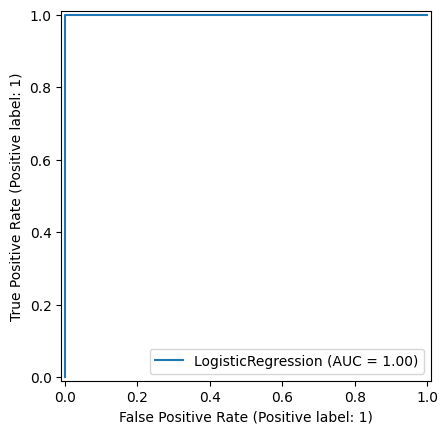

In [20]:
RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.show()

In [21]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print("K-Fold Scores:", scores)

print("Average Accuracy:", scores.mean())

K-Fold Scores: [1.  0.5 0.5 1.  0.5]
Average Accuracy: 0.7


In [22]:
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skfold, scoring="accuracy")

print("Stratified K-Fold Scores:", scores)

print("Average Accuracy:", scores.mean())

Stratified K-Fold Scores: [0.5 0.5 0.5 1.  0.5]
Average Accuracy: 0.6


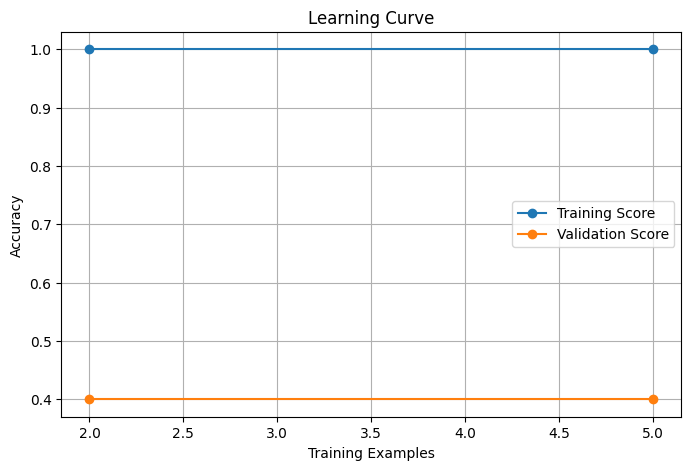

In [26]:
import warnings
import numpy as np
from sklearn.exceptions import FitFailedWarning
from sklearn.model_selection import learning_curve

# Ignore warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    cv=2,
    train_sizes=[0.5, 1.0],
    scoring="accuracy",
    error_score=np.nan
)

train_mean = np.nanmean(train_scores, axis=1)
test_mean = np.nanmean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Score')
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()